# Interdependence of Ruble and Yuan Borrowing Rates
## Statistical Analysis

This notebook analyses the relationship between Russian and Chinese borrowing rates
using data from CBR, MOEX, FRED, and AKShare.

**Structure:**
1. Data loading & cleanup
2. Descriptive statistics
3. Correlation analysis
4. Time-series diagnostics (stationarity)
5. Cointegration & Granger causality
6. VAR model
7. Visualisations

In [16]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from scipy import stats

from src.database import DatabaseManager

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

db = DatabaseManager()
print('Setup complete.')

Setup complete.


## 1. Load & Clean Data

In [17]:
cbr_key   = db.load_dataframe('cbr_key_rate')
gcurve    = db.load_dataframe('cbr_gcurve')
fx        = db.load_dataframe('currency_rates')
ofz       = db.load_dataframe('russian_bond_yields')
ru_macro  = db.load_dataframe('russian_macro')
pboc      = db.load_dataframe('pboc_lpr')
cn_bonds  = db.load_dataframe('chinese_bond_yields')
cn_macro  = db.load_dataframe('chinese_macro')
glob_ind  = db.load_dataframe('global_indicators')
biz_act   = db.load_dataframe('business_activity')

tables = {
    'cbr_key_rate': cbr_key, 'cbr_gcurve': gcurve, 'currency_rates': fx,
    'russian_bond_yields': ofz, 'russian_macro': ru_macro,
    'pboc_lpr': pboc, 'chinese_bond_yields': cn_bonds,
    'chinese_macro': cn_macro, 'global_indicators': glob_ind,
    'business_activity': biz_act,
}

print(f"{'Table':<25} {'Rows':>6}  {'Cols':>4}  Date range")
print('-' * 75)
for name, df in tables.items():
    if df.empty:
        print(f"{name:<25} {'empty':>6}")
        continue
    dr = ''
    if 'date' in df.columns:
        dr = f"{df['date'].min().strftime('%Y-%m')} .. {df['date'].max().strftime('%Y-%m')}"
    print(f"{name:<25} {len(df):>6}  {len(df.columns):>4}  {dr}")

Table                       Rows  Cols  Date range
---------------------------------------------------------------------------
cbr_key_rate                 150     2  2013-09 .. 2026-02
cbr_gcurve                   133     5  2015-01 .. 2026-01
currency_rates               134     4  2015-01 .. 2026-02
russian_bond_yields           85     8  2019-02 .. 2026-02
russian_macro                 87     3  2015-01 .. 2022-03
pboc_lpr                    1568     5  1991-04 .. 2026-01
chinese_bond_yields           12     9  2020-02 .. 2021-01
chinese_macro               3718    23  1981-02 .. 2026-02
global_indicators            134     8  2015-01 .. 2026-02
business_activity            132     4  2015-01 .. 2025-12


### Build a clean analysis panel

All dates are normalised to the 1st of each month so that merges align correctly
(different sources use end-of-month, 1st-of-month, or mid-month dates).
We keep the 2019-01 to 2026-02 window where most series overlap.

In [18]:
def to_month(df):
    """Normalise date to 1st-of-month; keep last row per month."""
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['_m'] = df['date'].dt.to_period('M')
    df = df.sort_values('date').groupby('_m').last().reset_index()
    df['date'] = df['_m'].dt.to_timestamp()
    return df.drop(columns=['_m'])

def force_numeric(df):
    """Convert every non-date column to float (None -> NaN)."""
    df = df.copy()
    for c in df.columns:
        if c != 'date':
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

def prep(df, cols=None):
    """Select columns, normalise month, force numeric, drop all-NaN cols."""
    if cols:
        cols = [c for c in cols if c in df.columns]
        df = df[cols]
    df = force_numeric(to_month(df))
    return df.dropna(axis=1, how='all')

# ---- Prepare each source ----
p_key  = prep(cbr_key, ['date', 'cbr_key_rate'])
p_gc   = prep(gcurve,  ['date', 'RU_1Y', 'RU_3Y', 'RU_5Y', 'RU_10Y'])
p_fx   = prep(fx,      ['date', 'usd_rub', 'cny_rub'])

# OFZ yields: rename to OFZ_* to distinguish from G-curve
ofz_cols = ['date'] + [c for c in ofz.columns if c.startswith('RU_')]
p_ofz  = prep(ofz, ofz_cols)
p_ofz  = p_ofz.rename(columns={c: f'OFZ_{c}' for c in p_ofz.columns if c.startswith('RU_')})

# PBOC LPR
lpr_cols = ['date'] + [c for c in pboc.columns if 'LPR' in c.upper()]
p_lpr  = prep(pboc, lpr_cols) if len(lpr_cols) > 1 else pd.DataFrame({'date': pd.Series(dtype='datetime64[ns]')})

# Chinese bond yields
if not cn_bonds.empty:
    cn_cols = ['date'] + [c for c in cn_bonds.columns if c.startswith('CN_')]
    p_cn = prep(cn_bonds, cn_cols)
else:
    p_cn = pd.DataFrame({'date': pd.Series(dtype='datetime64[ns]')})

# Global indicators
gi_cols = ['date', 'DGS10', 'DGS2', 'FEDFUNDS', 'DCOILBRENTEU', 'DTWEXBGS']
p_gi   = prep(glob_ind, gi_cols)

# ---- Merge all on normalised month ----
frames = [p_key, p_gc, p_fx, p_ofz, p_lpr, p_cn, p_gi]
panel = frames[0]
for df in frames[1:]:
    if df.empty or 'date' not in df.columns or len(df.columns) <= 1:
        continue
    panel = panel.merge(df, on='date', how='outer')

panel = panel.sort_values('date').reset_index(drop=True)
panel = panel[(panel['date'] >= '2019-01-01') & (panel['date'] <= '2026-02-01')]
panel = panel.dropna(axis=1, how='all')
panel = panel.set_index('date')

# Ensure all values are truly float (no hidden None objects)
for c in panel.columns:
    panel[c] = pd.to_numeric(panel[c], errors='coerce')

print(f"Panel shape: {panel.shape}")
print(f"Date range:  {panel.index.min().strftime('%Y-%m')} to {panel.index.max().strftime('%Y-%m')}")
print(f"\nColumns ({len(panel.columns)}):")
for c in panel.columns:
    non_null = panel[c].notna().sum()
    print(f"  {c:<25} {non_null:>4} / {len(panel)} non-null")

Panel shape: (86, 25)
Date range:  2019-01 to 2026-02

Columns (25):
  cbr_key_rate                86 / 86 non-null
  usd_rub                     86 / 86 non-null
  cny_rub                     86 / 86 non-null
  OFZ_RU_10Y                  57 / 86 non-null
  OFZ_RU_15Y                  57 / 86 non-null
  OFZ_RU_20Y                  38 / 86 non-null
  OFZ_RU_2Y                   85 / 86 non-null
  OFZ_RU_3Y                   75 / 86 non-null
  OFZ_RU_5Y                   65 / 86 non-null
  OFZ_RU_7Y                   57 / 86 non-null
  LPR1Y                       85 / 86 non-null
  LPR5Y                       78 / 86 non-null
  CN_3M                       12 / 86 non-null
  CN_6M                       12 / 86 non-null
  CN_1Y                       12 / 86 non-null
  CN_3Y                       12 / 86 non-null
  CN_5Y                       12 / 86 non-null
  CN_7Y                       12 / 86 non-null
  CN_10Y                      12 / 86 non-null
  CN_30Y                      12 / 86 

## 2. Descriptive Statistics

In [19]:
desc = panel.describe().T
desc['missing_%'] = ((panel.isna().sum() / len(panel)) * 100).round(1)
desc['skewness'] = panel.skew()
desc['kurtosis'] = panel.kurtosis()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,missing_%,skewness,kurtosis
cbr_key_rate,86.0,11.012,5.759,4.250,6.500,7.750,16.000,21.000,0.0,0.520,-1.305
usd_rub,86.0,77.067,11.331,51.158,69.682,75.796,83.984,107.741,0.0,0.309,-0.290
cny_rub,86.0,11.086,1.448,7.698,9.886,11.283,11.927,14.723,0.0,-0.159,-0.363
OFZ_RU_10Y,57.0,11.982,2.660,7.276,10.137,11.969,14.121,16.167,33.7,-0.135,-1.179
OFZ_RU_15Y,57.0,12.182,3.057,7.090,10.055,11.883,14.680,17.974,33.7,0.110,-1.121
OFZ_RU_20Y,38.0,13.769,2.620,9.696,11.803,14.168,15.841,18.979,55.8,0.066,-0.885
OFZ_RU_2Y,85.0,10.327,4.142,5.256,6.918,8.708,13.146,21.114,1.2,0.828,-0.364
OFZ_RU_3Y,75.0,10.725,4.108,5.349,6.946,9.342,13.929,20.249,12.8,0.527,-0.763
OFZ_RU_5Y,65.0,11.470,3.430,5.950,8.925,10.778,14.440,18.026,24.4,0.107,-1.122
OFZ_RU_7Y,57.0,12.218,3.258,7.059,9.815,11.850,14.446,19.079,33.7,0.291,-0.900


## 3. Time Series Visualisation

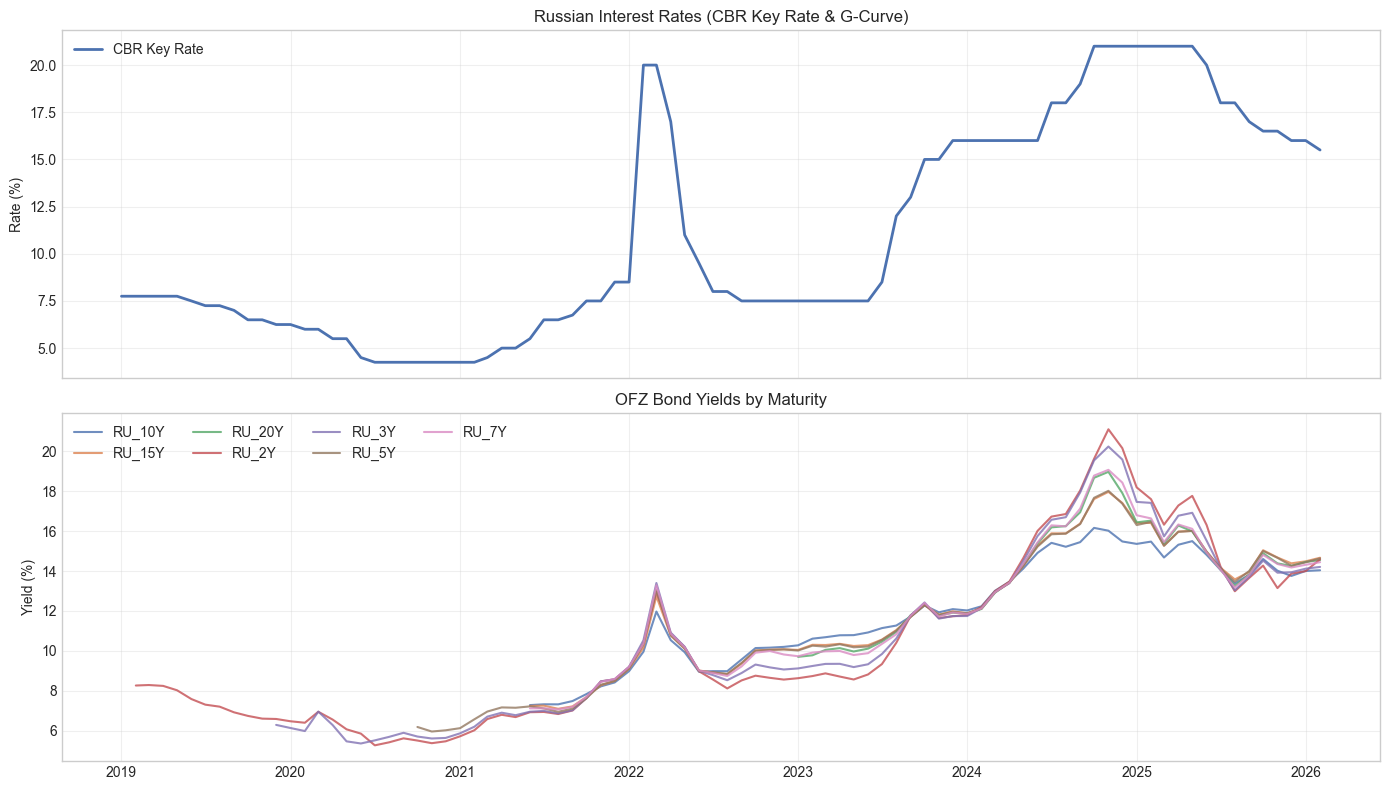

In [20]:
# Plot 1: Russian interest rates
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
s = panel['cbr_key_rate'].dropna()
if len(s) > 0:
    ax.plot(s.index, s.values, label='CBR Key Rate', lw=2)
for col in ['RU_1Y', 'RU_5Y', 'RU_10Y']:
    if col in panel.columns:
        s = panel[col].dropna()
        if len(s) > 0:
            ax.plot(s.index, s.values, label=f'G-Curve {col}', alpha=0.8)
ax.set_ylabel('Rate (%)')
ax.set_title('Russian Interest Rates (CBR Key Rate & G-Curve)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

ax = axes[1]
ofz_plot_cols = sorted([c for c in panel.columns if c.startswith('OFZ_')])
for col in ofz_plot_cols:
    s = panel[col].dropna()
    if len(s) > 0:
        ax.plot(s.index, s.values, label=col.replace('OFZ_', ''), alpha=0.8)
ax.set_ylabel('Yield (%)')
ax.set_title('OFZ Bond Yields by Maturity')
ax.legend(loc='upper left', ncol=4)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

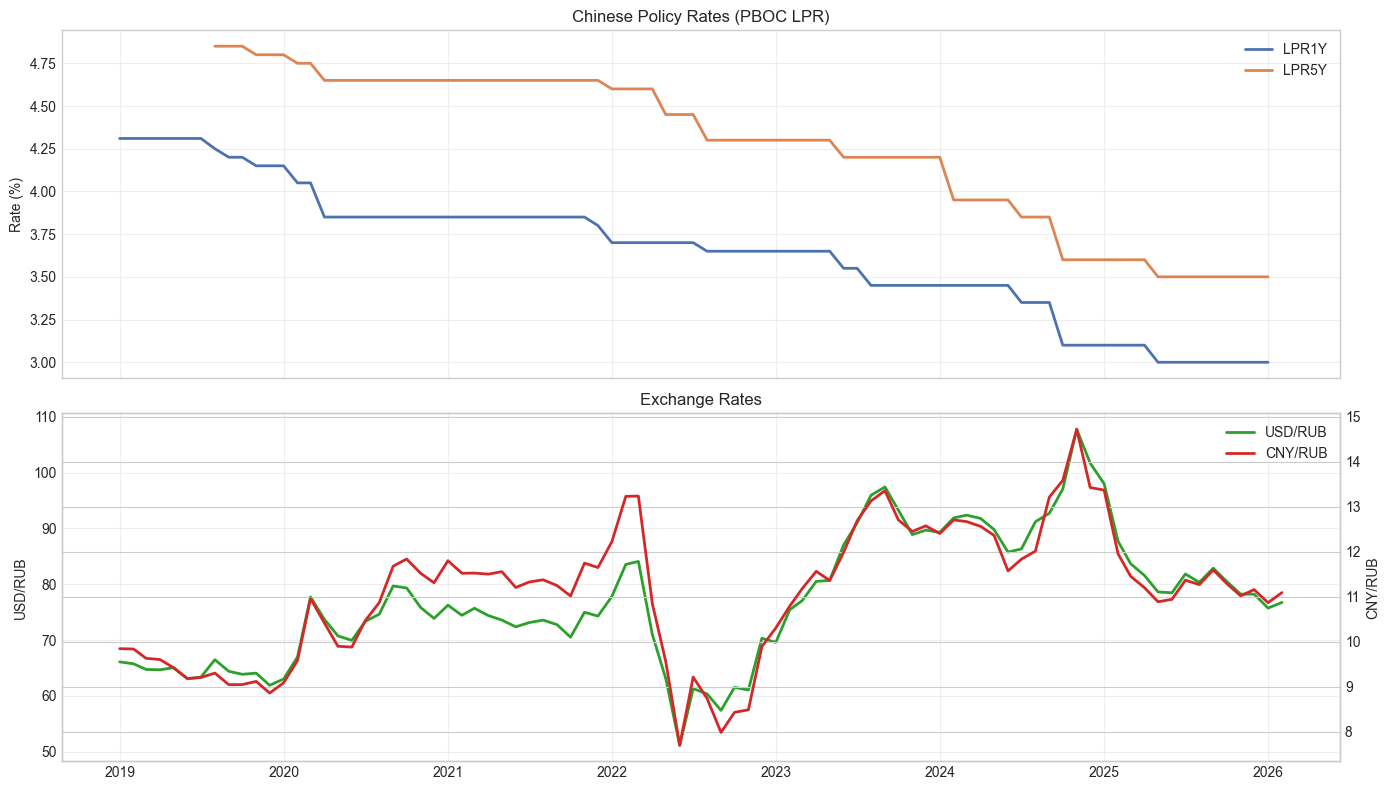

In [21]:
# Plot 2: Chinese rates & exchange rates
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
for col in [c for c in panel.columns if 'LPR' in c.upper()]:
    s = panel[col].dropna()
    if len(s) > 0:
        ax.plot(s.index, s.values, label=col, lw=2)
ax.set_ylabel('Rate (%)')
ax.set_title('Chinese Policy Rates (PBOC LPR)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
if 'usd_rub' in panel.columns:
    s = panel['usd_rub'].dropna()
    if len(s) > 0:
        ax.plot(s.index, s.values, label='USD/RUB', lw=2, color='tab:green')
ax.set_ylabel('USD/RUB')
ax2 = ax.twinx()
if 'cny_rub' in panel.columns:
    s = panel['cny_rub'].dropna()
    if len(s) > 0:
        ax2.plot(s.index, s.values, label='CNY/RUB', lw=2, color='tab:red')
ax2.set_ylabel('CNY/RUB')
ax.set_title('Exchange Rates')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

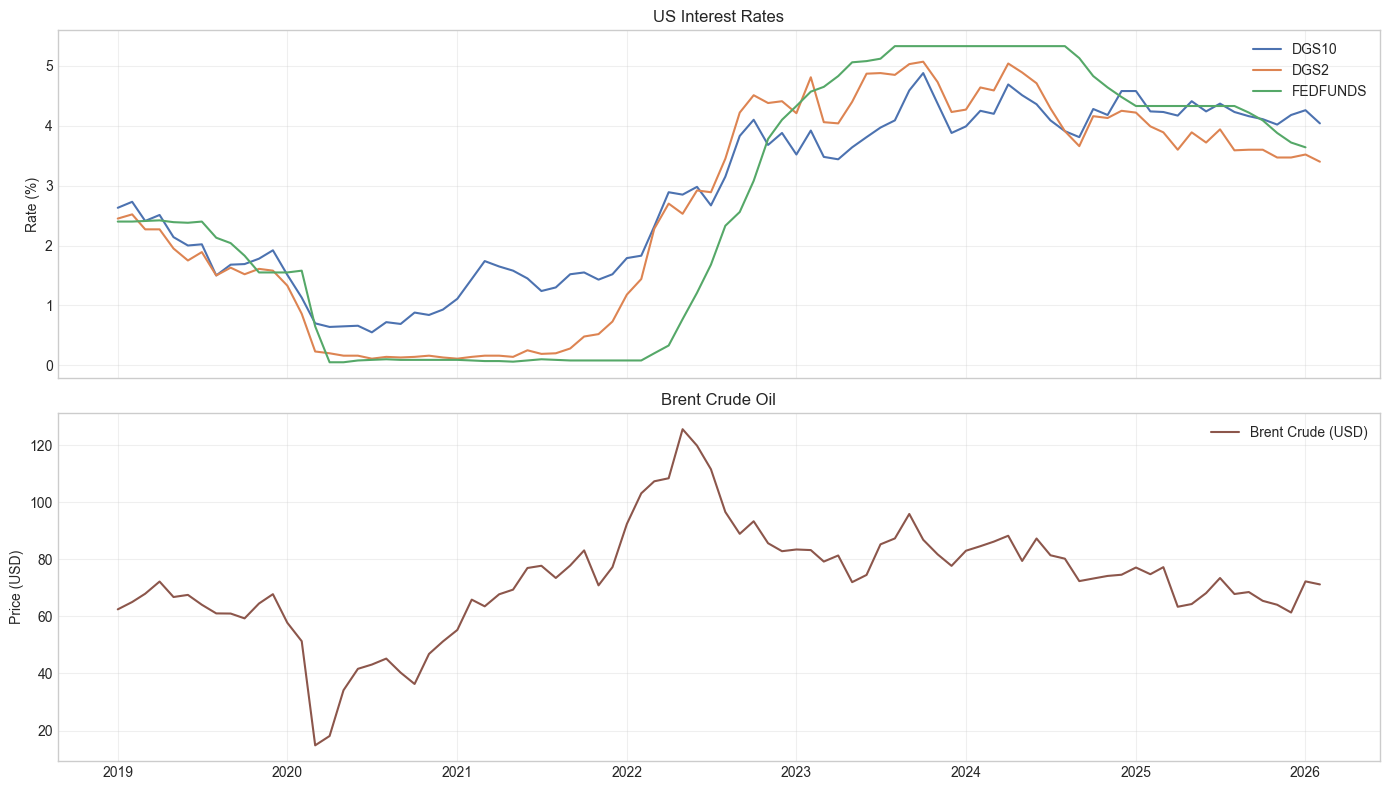

In [22]:
# Plot 3: Global context
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
for col in ['DGS10', 'DGS2', 'FEDFUNDS']:
    if col in panel.columns:
        s = panel[col].dropna()
        if len(s) > 0:
            ax.plot(s.index, s.values, label=col, lw=1.5)
ax.set_ylabel('Rate (%)')
ax.set_title('US Interest Rates')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
if 'DCOILBRENTEU' in panel.columns:
    s = panel['DCOILBRENTEU'].dropna()
    if len(s) > 0:
        ax.plot(s.index, s.values, label='Brent Crude (USD)', color='tab:brown', lw=1.5)
ax.set_ylabel('Price (USD)')
ax.set_title('Brent Crude Oil')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Correlation Analysis

Correlation matrix: 15 variables (pairwise, min 20 obs)


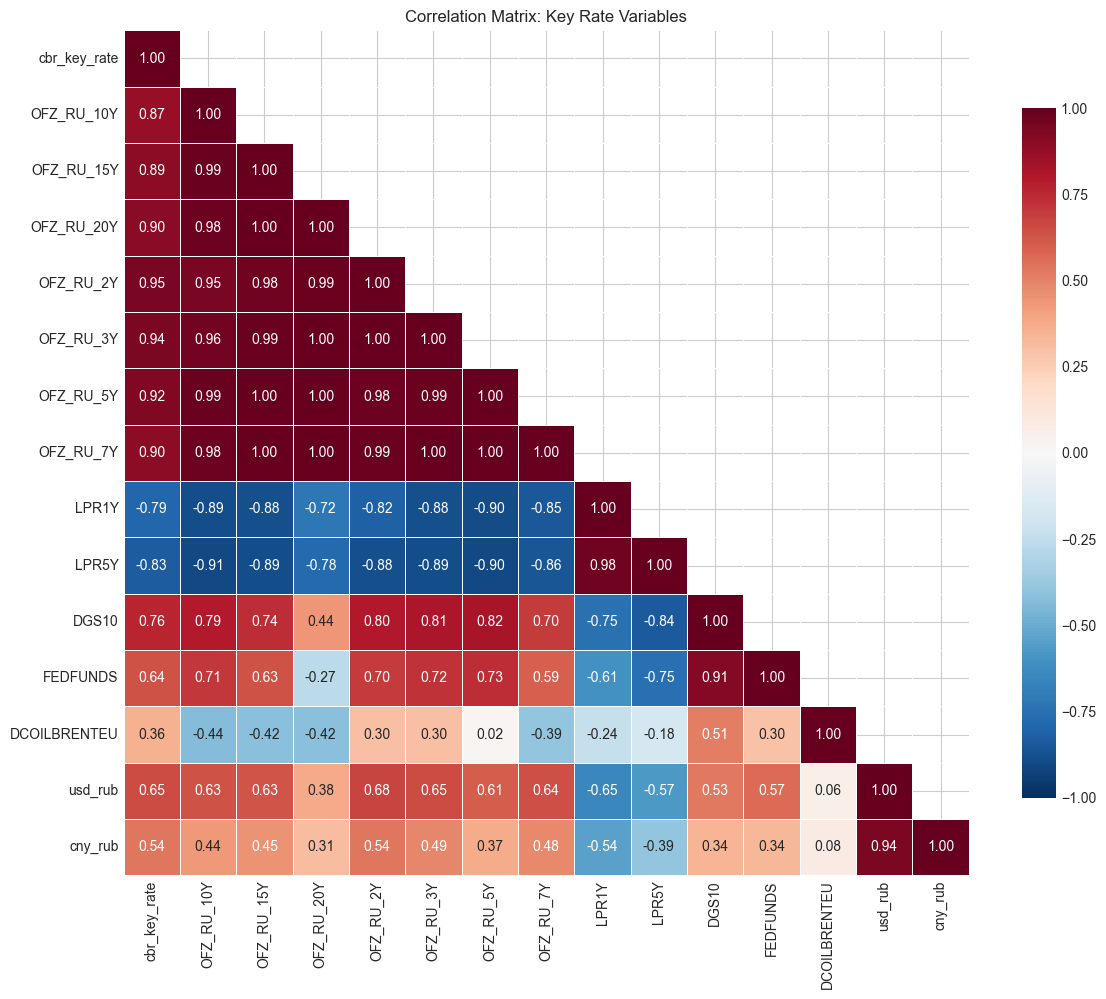

In [23]:
# Select core rate variables that have enough data
MIN_OBS = 30

rate_vars = []
candidates = (
    ['cbr_key_rate']
    + [c for c in ['RU_1Y', 'RU_5Y', 'RU_10Y'] if c in panel.columns]
    + sorted([c for c in panel.columns if c.startswith('OFZ_RU_')])
    + [c for c in panel.columns if 'LPR' in c.upper()]
    + [c for c in ['DGS10', 'FEDFUNDS', 'DCOILBRENTEU', 'usd_rub', 'cny_rub'] if c in panel.columns]
)
for v in candidates:
    if v in panel.columns and panel[v].notna().sum() >= MIN_OBS and v not in rate_vars:
        rate_vars.append(v)

# Pairwise correlation (not listwise deletion)
corr = panel[rate_vars].corr(min_periods=20)
print(f"Correlation matrix: {len(rate_vars)} variables (pairwise, min 20 obs)")

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix: Key Rate Variables')
plt.tight_layout()
plt.show()

## 5. Stationarity Tests (Augmented Dickey-Fuller)

In [24]:
def adf_summary(series, name):
    """Run ADF test; returns dict. Handles NaN gracefully."""
    s = pd.to_numeric(series, errors='coerce').dropna()
    if len(s) < 20:
        return {'variable': name, 'n': len(s), 'adf_stat': np.nan,
                'p_value': np.nan, 'stationary': 'too few obs'}
    result = adfuller(s.values, autolag='AIC')
    return {
        'variable': name, 'n': len(s),
        'adf_stat': round(result[0], 4),
        'p_value': round(result[1], 4),
        'lags_used': result[2],
        'stationary': 'Yes' if result[1] < 0.05 else 'No',
    }

test_vars = [v for v in rate_vars if panel[v].notna().sum() >= 30]

adf_results = []
for v in test_vars:
    adf_results.append(adf_summary(panel[v], v))
    # First difference: compute on .values to avoid None subtraction
    s = pd.to_numeric(panel[v], errors='coerce')
    d = s.diff()
    adf_results.append(adf_summary(d, f'd({v})'))

adf_df = pd.DataFrame(adf_results)
adf_df

,variable,n,adf_stat,p_value,lags_used,stationary
0,cbr_key_rate,86,-1.1628,0.6894,3,No
1,d(cbr_key_rate),85,-6.1551,0.0000,2,Yes
2,OFZ_RU_10Y,57,-1.7022,0.4300,1,No
3,d(OFZ_RU_10Y),56,-6.0785,0.0000,0,Yes
4,OFZ_RU_15Y,57,-1.5778,0.4947,1,No
5,d(OFZ_RU_15Y),56,-6.0433,0.0000,0,Yes
6,OFZ_RU_20Y,38,-1.7278,0.4169,1,No
7,d(OFZ_RU_20Y),37,-4.1411,0.0008,0,Yes
8,OFZ_RU_2Y,85,-1.0604,0.7306,1,No
9,d(OFZ_RU_2Y),84,-6.2745,0.0000,0,Yes


## 6. Cointegration Tests

In [25]:
coint_pairs = []

ru_rates = ['cbr_key_rate'] + [c for c in ['RU_5Y', 'RU_10Y'] if c in panel.columns]
# If no G-curve data, use OFZ yields
if not any(c.startswith('RU_') and not c.startswith('OFZ_') for c in ru_rates[1:]):
    ru_rates += [c for c in ['OFZ_RU_2Y', 'OFZ_RU_5Y', 'OFZ_RU_10Y'] if c in panel.columns]

cn_rates = [c for c in panel.columns if 'LPR' in c.upper()]
other_rates = [c for c in ['DGS10', 'FEDFUNDS', 'DCOILBRENTEU'] if c in panel.columns]

for ru in ru_rates:
    for partner in cn_rates + other_rates:
        pair = panel[[ru, partner]].dropna()
        if len(pair) < 30:
            continue
        score, pval, _ = coint(pair[ru].values, pair[partner].values)
        coint_pairs.append({
            'series_1': ru, 'series_2': partner,
            'n': len(pair),
            'test_stat': round(score, 4),
            'p_value': round(pval, 4),
            'cointegrated': 'Yes' if pval < 0.05 else 'No',
        })

coint_df = pd.DataFrame(coint_pairs)
if coint_df.empty:
    print('No pairs with sufficient overlapping data (>=30 obs) for cointegration testing.')
else:
    display(coint_df)

,series_1,series_2,n,test_stat,p_value,cointegrated
0,cbr_key_rate,LPR1Y,85,-2.6870,0.2043,No
1,cbr_key_rate,LPR5Y,78,-3.1115,0.0860,No
2,cbr_key_rate,DGS10,86,-2.7139,0.1946,No
3,cbr_key_rate,FEDFUNDS,85,-2.3760,0.3363,No
4,cbr_key_rate,DCOILBRENTEU,86,-1.1143,0.8789,No
5,OFZ_RU_2Y,LPR1Y,84,-2.1871,0.4310,No
6,OFZ_RU_2Y,LPR5Y,78,-2.4134,0.3185,No
7,OFZ_RU_2Y,DGS10,85,-1.8122,0.6238,No
8,OFZ_RU_2Y,FEDFUNDS,84,-2.1101,0.4711,No
9,OFZ_RU_2Y,DCOILBRENTEU,85,-1.1700,0.8656,No


## 7. Granger Causality Tests

In [26]:
def granger_test(data, col1, col2, max_lag=6):
    """Test whether col2 Granger-causes col1 (on first-differenced data)."""
    pair = data[[col1, col2]].dropna()
    if len(pair) < max_lag * 4:
        return None
    try:
        result = grangercausalitytests(pair.values, max_lag, verbose=False)
        pvals = {lag: round(result[lag][0]['ssr_ftest'][1], 4) for lag in range(1, max_lag + 1)}
        best_lag = min(pvals, key=pvals.get)
        return {
            'cause': col2, 'effect': col1,
            'best_lag': best_lag,
            'best_p': pvals[best_lag],
            'significant': 'Yes' if pvals[best_lag] < 0.05 else 'No',
            'n': len(pair),
        }
    except Exception:
        return None

# First-difference the panel (removes unit roots)
dpanel = panel.apply(pd.to_numeric, errors='coerce').diff().dropna(how='all')

granger_results = []
g_ru  = [v for v in ru_rates if v in dpanel.columns]
g_cn  = [v for v in cn_rates if v in dpanel.columns]
g_gl  = [c for c in ['DGS10', 'FEDFUNDS', 'DCOILBRENTEU'] if c in dpanel.columns]

for ru in g_ru:
    for partner in g_cn + g_gl:
        r = granger_test(dpanel, ru, partner)
        if r: granger_results.append(r)
        r = granger_test(dpanel, partner, ru)
        if r: granger_results.append(r)

granger_df = pd.DataFrame(granger_results)
if granger_df.empty:
    print('No Granger causality results (insufficient data overlap).')
else:
    granger_df = granger_df.sort_values('best_p')
    display(granger_df[['cause', 'effect', 'best_lag', 'best_p', 'significant', 'n']])

,cause,effect,best_lag,best_p,significant,n
3,cbr_key_rate,LPR5Y,6,0.0126,Yes,77
9,cbr_key_rate,DCOILBRENTEU,3,0.0143,Yes,85
10,LPR1Y,OFZ_RU_2Y,5,0.0178,Yes,83
5,cbr_key_rate,DGS10,6,0.0219,Yes,85
15,OFZ_RU_2Y,DGS10,1,0.0222,Yes,84
27,OFZ_RU_5Y,FEDFUNDS,6,0.0236,Yes,63
11,OFZ_RU_2Y,LPR1Y,1,0.0480,Yes,83
25,OFZ_RU_5Y,DGS10,1,0.0808,No,64
26,FEDFUNDS,OFZ_RU_5Y,2,0.0845,No,63
29,OFZ_RU_5Y,DCOILBRENTEU,3,0.0871,No,64


## 8. VAR Model

In [27]:
# Pick variables for VAR: CBR key rate, first LPR, DGS10, oil
var_candidates = ['cbr_key_rate']
var_candidates += [c for c in dpanel.columns if 'LPR' in c.upper()][:1]
var_candidates += [c for c in ['DGS10', 'DCOILBRENTEU'] if c in dpanel.columns]
var_candidates = [c for c in var_candidates if c in dpanel.columns]

var_data = dpanel[var_candidates].dropna()
print(f"VAR data: {var_data.shape[0]} obs, variables: {list(var_data.columns)}")

if len(var_data) >= 30:
    model = VAR(var_data)
    lag_order = model.select_order(maxlags=8)
    print('\nLag order selection:')
    print(lag_order.summary())

    best_lag = max(lag_order.aic, 1)
    print(f'\nFitting VAR({best_lag})...')
    fitted = model.fit(best_lag)
    print(fitted.summary())
else:
    fitted = None
    print('Insufficient data for VAR estimation.')

VAR data: 84 obs, variables: ['cbr_key_rate', 'LPR1Y', 'DGS10', 'DCOILBRENTEU']


TypeError: VAR.__init__() got an unexpected keyword argument 'names'. Did you mean 'dates'?

In [ ]:
if fitted is not None:
    irf = fitted.irf(periods=12)
    fig = irf.plot(orth=False, figsize=(14, 10))
    plt.suptitle('Impulse Response Functions (12-month horizon)', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    fevd = fitted.fevd(periods=12)
    fevd.summary()
else:
    print('Skipping IRF (no VAR fitted).')

## 9. Regression: CBR Key Rate Determinants

In [ ]:
y_col = 'cbr_key_rate'
x_candidates = []
x_candidates += [c for c in panel.columns if 'LPR' in c.upper()][:1]
x_candidates += [c for c in ['DGS10', 'FEDFUNDS', 'DCOILBRENTEU', 'usd_rub'] if c in panel.columns]

reg_data = panel[[y_col] + x_candidates].dropna()
print(f"Regression sample: {len(reg_data)} observations")
print(f"Dependent: {y_col}")
print(f"Independent: {x_candidates}")

if len(reg_data) > len(x_candidates) + 5:
    X = sm.add_constant(reg_data[x_candidates].astype(float))
    y = reg_data[y_col].astype(float)
    ols = sm.OLS(y, X).fit(cov_type='HC1')
    print(ols.summary())
else:
    print('Insufficient data for regression.')

## 10. Summary & Key Findings

In [ ]:
print('=' * 70)
print('SUMMARY OF STATISTICAL ANALYSIS')
print('=' * 70)

print(f'\nData period: {panel.index.min().strftime("%Y-%m")} to {panel.index.max().strftime("%Y-%m")}')
print(f'Observations: {len(panel)}')

print('\n--- Stationarity (ADF) ---')
levels = adf_df[~adf_df['variable'].str.startswith('d(')]
diffs = adf_df[adf_df['variable'].str.startswith('d(')]
print(f'  Stationary in levels: {(levels["stationary"]=="Yes").sum()} / {len(levels)}')
print(f'  Stationary after differencing: {(diffs["stationary"]=="Yes").sum()} / {len(diffs)}')

if not coint_df.empty:
    print('\n--- Cointegration ---')
    n_coint = (coint_df['cointegrated'] == 'Yes').sum()
    print(f'  Cointegrated pairs: {n_coint} / {len(coint_df)}')
    if n_coint > 0:
        print('  Significant pairs:')
        for _, row in coint_df[coint_df['cointegrated'] == 'Yes'].iterrows():
            print(f'    {row["series_1"]} <-> {row["series_2"]}  (p={row["p_value"]})')

if not granger_df.empty:
    print('\n--- Granger Causality ---')
    sig = granger_df[granger_df['significant'] == 'Yes']
    print(f'  Significant causal links: {len(sig)} / {len(granger_df)}')
    for _, row in sig.head(10).iterrows():
        print(f'    {row["cause"]} -> {row["effect"]}  (lag={row["best_lag"]}, p={row["best_p"]})')

print('\n' + '=' * 70)